# How to Create an Artificial UFD Candidate

This tutorial will walk you through the process of generating an artificial candidate. At the end of the tutorial, there is a section titled "Other helpful tips" that provides details on training a GMM from scratch, creating multiple galaxies with random parameters, and rescaling images.

### 0. Import Necessary Packages

In [1]:
from myplotstyle import plt
from astropy import units as u
import numpy as np

from artificial_galaxy_pipeline import ArtificialGalaxy, BackgroundImage, ImageInjector, artificial_galaxy_generator
from artificial_galaxy_pipeline.gmm import GMM, GMMBuilder
from artificial_galaxy_pipeline.viz import SourceData

/uufs/astro.utah.edu/common/home/u6039755/python/artgal/.venv/lib/python3.14/site-packages/colorspacious/comparison.py:11: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  """Computes the :math:`\Delta E` distance between pairs of colors.


### 1. Generate the injected stellar sources

We’ll will start by specifying the parameters for the galaxy we want to create, and passing them into the <small>`ArtificialGalaxy`</small> class. This class generates the magnitude and posititon data for the artificial stellar sources based on the provided parameteres.

Here we use an example of known [Leo K dwarf galaxy](https://iopscience.iop.org/article/10.3847/1538-4357/ad429b).

In [2]:
leo_k = ArtificialGalaxy(
    name="Leo_K",
    log_age=10.08,
    feh=-1.88,
    total_mass=1.9e4 * u.Msun,
    scale_radius=71.54 * u.pc,
    distance=0.43 * u.Mpc,
)

# This shows the properties of the artificial stars in the galaxy
leo_k.source_table[:10] 

x,y,g_mag,r_mag,gr,name,pixel_scale,size
float64,float64,float64,float64,float64,str5,float64,int64
418.2767488035145,484.70724015900925,33.12647591697591,32.03623649424895,1.0902394227269596,Leo_K,0.262,901
622.3528902348031,367.99507189550275,36.159667973933196,34.69647559123179,1.4631923827014077,Leo_K,0.262,901
440.73045741322153,481.93118913277715,31.31294392951458,30.556583817310578,0.7563601122040033,Leo_K,0.262,901
58.94725606909276,623.6081134726312,36.618567387432435,35.089429973976905,1.5291374134555298,Leo_K,0.262,901
458.34074977253016,265.62757520329023,34.170542604833386,32.971370605739835,1.1991719990935508,Leo_K,0.262,901
471.55996977272804,404.24913791582213,30.355408308067954,29.786991048617754,0.5684172594502002,Leo_K,0.262,901
413.43326250469,439.19858174311787,36.159463351353104,34.69630114275999,1.4631622085931113,Leo_K,0.262,901
580.7440862833305,669.2379891617773,34.440370013392496,33.219009500418494,1.2213605129740017,Leo_K,0.262,901
484.1397474435692,303.0276331404551,34.402459391442086,33.184624517548485,1.217834873893601,Leo_K,0.262,901


### 2. Obtain the Background 

We then need to obtain the real sky background we plan to inject into. We will create an instance of  <small>`BackgroundImage`</small> class.

(np.float64(-0.5), np.float64(900.5), np.float64(900.5), np.float64(-0.5))

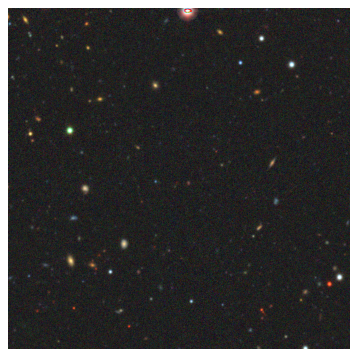

In [3]:
background = BackgroundImage(ra=182.5002, dec=12.5554)

fig = plt.figure(dpi=80)
plt.imshow(background.rgb)
plt.axis('off')

### 3. Inject the stellar sources into the background image

We will pass in our artifical galaxy and background to <small>`ImageInjector`</small> which handles the injection process.

Injecting Leo_K at position [450 450]


(np.float64(-0.5), np.float64(900.5), np.float64(900.5), np.float64(-0.5))

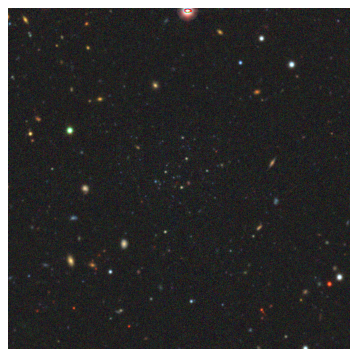

In [4]:
injector = ImageInjector(leo_k, background)

fig = plt.figure(dpi=80)
plt.imshow(injector.rgb)
plt.axis('off')

### 4. Obtain the pre-trained GMM

Before we create the diagnostic plot we need to load in the pre-trained GMM. The GMM is trained on 200 images of artificial UFDs. 

You can download pre-trained GMM file [here](https://github.com/alexb000/artificial-galaxy-pipeline/blob/main/trained_gmm.pkl).

**Note:** If you are interested in training a GMM on new data see section "Training a GMM" at the bottom of the tutorial.


In [5]:
gmm = GMM(model_path="trained_gmm.pkl")      # Returns the pre-trained GMM

Loading model from trained_gmm.pkl
GMM model successfully loaded from trained_gmm.pkl


/uufs/astro.utah.edu/common/home/u6039755/python/artgal/.venv/lib/python3.14/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator GaussianMixture from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


### 5. : Create the Diagnostic Plot

Once you have an instance of <small>`ImageInjector`</small>, and <small>`BackgroundImage`</small> you can access both the observed magnitude table and the RGB image of your injected galaxy.  With this information, we can create an instance of the <small>`SourceData`</small> class, which generates a diagnostic plot similar to the multi-panel figures shown in the research note (*link*).  

This diagnostic plot includes:
- density plot
- color–magnitude diagram (CMDs)
- hexbin plot

Number of rows in inj: 45


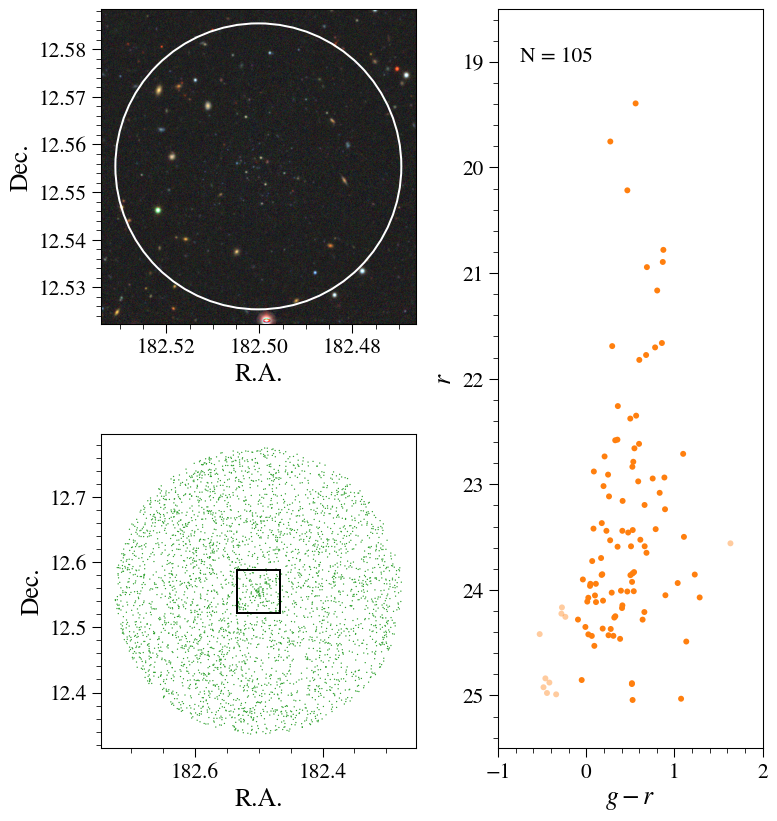

In [6]:
# obtain the observed magnitude table for the injected sources
observed_source_table = leo_k.get_observed_source_table(gmm, background.ra, background.dec) 

# obtain the injected image
rgb = injector.rgb 

source = SourceData(ra=background.ra,
                    dec=background.dec,
                    source_inj_table=observed_source_table,
                    inj_image=rgb)

source.make_plot_minimal()


# Other Helpful Tips

### 1. How to create a UFD Candidate(s) with random parameters
We can create two types of galaxy candidates:  
- Those with *specified feature parameters* (shown in step 1 of the tutorial above), or  
- Those with *random feature parameters* drawn from uniform distributions that match known ultra-faint dwarfs (UFDs).  The code below shows you have to create
galaxies with randomly generated parameters.


In [ ]:
for galaxy in artificial_galaxy_generator(num_sources=5):
    injector = ImageInjector(galaxy, background)

    # Save the image and source table to file
    injector.write_image_to_file(f"{galaxy.name}.fits")
    galaxy.write_source_table(f"{galaxy.name}.parquet")

    fig = plt.figure(dpi=80)
    plt.imshow(injector.rgb)
    plt.axis('off')
    plt.show()
    plt.close()
    

### 2. How to train a GMM
There are two ways to train a new GMM...

#### 2.1 Automatically generate new data to train a GMM

If you want to train a new GMM using freshly generated data, you can let <small>`GMMBuilder`</small> automatically create everything for you.

When initialized without specifying training or test names, <small>`GMMBuilder`</small> will:

- Generate (by default) 200 artificial UFDs for training and 100 artificial UFDs for testing,
- Create an instance of <small>`MagnitudeExtractor`</small> for each to image to preform source extraction and photometry.
- Train a new GMM using the extracted magnitudes


In [ ]:
builder = GMMBuilder()
gmm = builder.gmm

#### 2.2: Use existing artificial UFDs to train a GMM

If you already have FITS images and magnitude files from the injection process, you can pass in explicit galaxy names to <small>`GMMBuilder`</small>.

When initialized, <small>`GMMBuilder`</small> will automatically:

- Preform source extraction and photometry on the corresponding training and test files,
- Train the GMM using the extracted magnitudes.

In [ ]:
galaxy_names_train = [f"galaxy_train_{i:04d}" for i in range(200)]
galaxy_names_test  = [f"galaxy_test_{i:04d}" for i in range(100)]

builder = GMMBuilder(train_names=galaxy_names_train, test_names=galaxy_names_test, data_folder="gmm_training_data", model_path="new_trained_gmm.pkl")
gmm = builder.gmm

### 3.0: How to Rescale Images

The stand-alone function <small>`zoom_image`</small> in **core.py** handles the rescaling of the image bands. It loops through each band in the image dictionary and applies <small>`skimage.transform.rescale`</small> using the specified zoom factor.

The effective pixel scale after rescaling is

$$
\mathrm{new\ pixel\ scale} =
\frac{\mathrm{native\ pixel\ scale}}{\mathrm{zoom\ factor}}
$$

#### 3.1: Rescaling artifcial galaxy images

Artificial galaxy images should be rescaled only after injection into the background image. This keeps the artificial galaxy and background image on the same native pixel grid during the injection step. 

In [7]:
NATIVE_PIXEL_SCALE = 0.262
ZOOM_FACTOR = 0.282

Injecting Leo_K at position [450 450]
Image size after rescaling: (254, 254, 3) float32 0.0 1.0


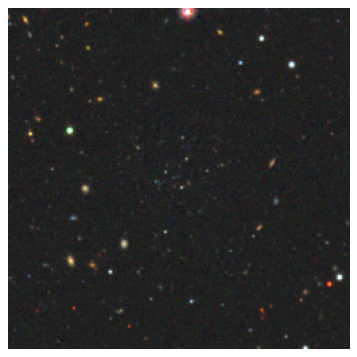

In [8]:
background = BackgroundImage(ra=182.5002, dec=12.5554)

injector = ImageInjector(leo_k, background, zoom_factor=ZOOM_FACTOR)
img = injector.rgb

fig = plt.figure(dpi=80)
plt.imshow(img)
plt.axis('off')
print("Image size after rescaling:", img.shape, img.dtype, np.min(img), np.max(img), flush=True)